# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
* I found that the data itself is right skewed, there is a tail on the right side
* So most of the gifts themselves are small, with a few institutions recieving larger gifts
* Since this is right skewed it can cause the data to pull up
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
* Proportion of Contracts: 0.6120973742957372
* Proportion of Real Estate: 0.00038978065979235324
* Proportion of Monetary Gifts: 0.3875128450444704
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
* I noticed that the Real Estate typically provided for larger gifts as it has the highest density in the upper ranges.
* It is followed by Contracts which has the next highest peak, at a little lower of a range on the log scale
* Then we see the next peak of all the gifts combined together, so we can see more directly what we were trying to see before without the skew
* And then we have monetary gifts which has the lowest density.
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

**Top 15 by number of gifts: Country of Giftor**
* ENGLAND            
* CHINA              
* CANADA             
* JAPAN              
* SWITZERLAND        
* SAUDI ARABIA       
* FRANCE             
* GERMANY            
* HONG KONG          
* SOUTH KOREA        
* QATAR              
* THE NETHERLANDS    
* KOREA              
* INDIA              
* TAIWAN             


**Top 15 by gift amount: Country of Giftor**
* QATAR                   
* ENGLAND                 
* CHINA                   
* SAUDI ARABIA            
* BERMUDA                 
* CANADA                  
* HONG KONG               
* JAPAN                   
* SWITZERLAND             
* INDIA                   
* GERMANY                 
* UNITED ARAB EMIRATES    
* FRANCE                  
* SINGAPORE               
* AUSTRALIA               
6. Which giftors provide the most money, in total?
* Qatar Foundation
* Qatar Foundation/Qatar National Res
* Qatar Foundation for Education     
* Anonymous                          
* Saudi Arabian Cultural Mission     
* HCL                                
* Church of Jesus Christ of LDS      
* Emirates Institute for Advanced Sc 
* QIC                                
* Anonymous #9                       
* Qatar National Research Fund       
* Government of Saudi Arabia         
* Contracting Party                  
* CMKL University                    
* Royal Embassy of Saudi Arabia      

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Jalen Medley

**Date:** 09/10/2026

Proportion of Contracts: 0.6120973742957372
Proportion of Real Estate: 0.00038978065979235324
Proportion of Monetary Gifts: 0.3875128450444704


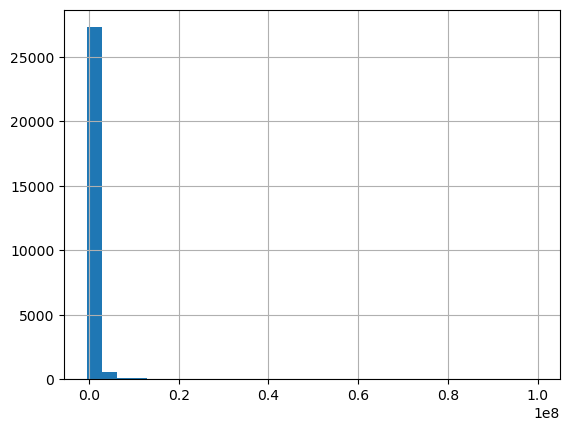

In [13]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('data/ForeignGifts_edu.csv')
# print(df['Foreign Gift Amount'].describe())
df['Foreign Gift Amount'].hist(bins=30)

values = df['Gift Type'].value_counts()
print("Proportion of Contracts: " + str(values['Contract'] / len(df)))
print("Proportion of Real Estate: " + str(values['Real Estate'] / len(df)))
print("Proportion of Monetary Gifts: " + str(values['Monetary Gift'] / len(df)))

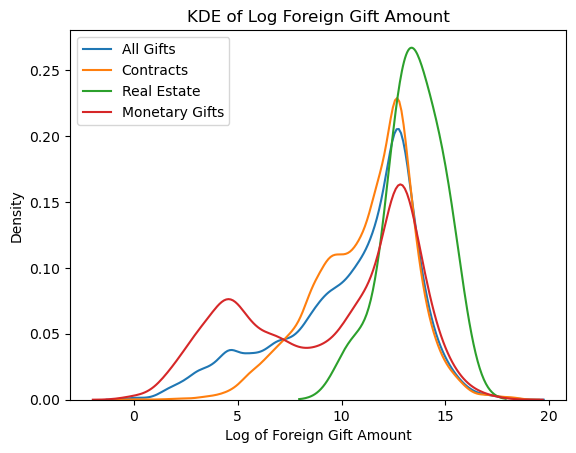

Top 15 by number of gifts: Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Top 15 by gift amount: Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA               

In [14]:
pos_vals = df[df['Foreign Gift Amount'] > 0].copy()
pos_vals['Foreign Gift Amount_log'] = np.log(pos_vals['Foreign Gift Amount'])

ax = sns.kdeplot(data=pos_vals, x="Foreign Gift Amount_log", bw_method='silverman', label="All Gifts")
ax.set(title="KDE of Log Foreign Gift Amount", xlabel="Log of Foreign Gift Amount", ylabel="Density")

contract = pos_vals[pos_vals['Gift Type'] == 'Contract']
ax1 = sns.kdeplot(data=contract, x="Foreign Gift Amount_log", bw_method='silverman', label="Contracts")

real = pos_vals[pos_vals['Gift Type'] == 'Real Estate']
ax2 = sns.kdeplot(data=real, x="Foreign Gift Amount_log", bw_method='silverman', label="Real Estate")

monGift = pos_vals[pos_vals['Gift Type'] == 'Monetary Gift']
ax3 = sns.kdeplot(data=monGift, x="Foreign Gift Amount_log", bw_method='silverman', label="Monetary Gifts")
plt.legend()
plt.show()


gift_count = df.groupby('Country of Giftor').count()['Foreign Gift Amount'].sort_values(ascending=False)
print("Top 15 by number of gifts: " + str(gift_count.head(15)))

gift_amount = df.groupby('Country of Giftor').sum()['Foreign Gift Amount'].sort_values(ascending=False)
print("Top 15 by gift amount: " + str(gift_amount.head(15)))

best_giftor = df.groupby('Giftor Name').sum()['Foreign Gift Amount'].sort_values(ascending=False)
print("Top Giftor: " + str(best_giftor.head(15)))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [15]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]